In [41]:
from pathlib import Path

import numpy as np
import pandas as pd

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt


In [17]:
DATA_DIR = Path(
    "../data/processed/model_splits"
)

train_data = pd.read_parquet(
    DATA_DIR / "train_engineered.parquet"
)

validation_data = pd.read_parquet(
    DATA_DIR / "validation_engineered.parquet"
)

test_data = pd.read_parquet(
    DATA_DIR / "test_engineered.parquet"
)

In [18]:
TARGET = "ClosePrice"

X_train = train_data.drop(
    columns=TARGET
)

y_train = train_data[TARGET]

X_validation = validation_data.drop(
    columns=TARGET
)

y_validation = validation_data[TARGET]

X_test = test_data.drop(
    columns=TARGET
)

y_test = test_data[TARGET]

In [19]:
print(X_train.shape, y_train.shape)
print(X_validation.shape, y_validation.shape)
print(X_test.shape, y_test.shape)

(292920, 32) (292920,)
(11880, 32) (11880,)
(11889, 32) (11889,)


In [20]:
X_train.dtypes

LivingArea               float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
LotSizeSquareFeet        float64
YearBuilt                float64
GarageSpaces             float64
ParkingTotal             float64
Stories                  float64
Latitude                 float64
Longitude                float64
PropertyAge              float64
BathBedRatio             float64
LivingAreaPerBedroom     float64
LivingAreaPerBathroom    float64
LotToLivingRatio         float64
LogLivingArea            float64
LogLotSize               float64
AmenityCount             float64
AmenityKnownCount          int64
CloseMonthSin            float64
CloseMonthCos            float64
PostalCode               float64
CountyOrParish            object
MLSAreaMajor              object
Levels                    object
PoolPrivateYN             object
ViewYN                    object
AttachedGarageYN          object
NewConstructionYN         object
FireplaceYN               object
City      

In [21]:
X_train.dtypes.value_counts()

float64    21
object     10
int64       1
Name: count, dtype: int64

In [22]:
CATEGORICAL_FEATURES = [
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "Levels",
    "PoolPrivateYN",
    "ViewYN",
    "AttachedGarageYN",
    "NewConstructionYN",
    "FireplaceYN",
    "City",
    "UnifiedSchoolDistrict"
]

In [23]:
for data in [
    X_train,
    X_validation,
    X_test
]:
    data["PostalCode"] = (
        data["PostalCode"]
        .astype("Int64")
        .astype("string")
        .astype("category")
    )

In [24]:
for feature in CATEGORICAL_FEATURES[1:]:
    X_train[feature] = (
        X_train[feature]
        .astype("category")
    )

    X_validation[feature] = (
        X_validation[feature]
        .astype("category")
    )

    X_test[feature] = (
        X_test[feature]
        .astype("category")
    )

In [25]:
for feature in CATEGORICAL_FEATURES:

    # PostalCode: numeric ZIP -> string
    if feature == "PostalCode":
        X_train[feature] = (
            X_train[feature]
            .astype("Int64")
            .astype("string")
        )

        X_validation[feature] = (
            X_validation[feature]
            .astype("Int64")
            .astype("string")
        )

        X_test[feature] = (
            X_test[feature]
            .astype("Int64")
            .astype("string")
        )

    # All other categorical features -> string
    else:
        X_train[feature] = (
            X_train[feature]
            .astype("string")
        )

        X_validation[feature] = (
            X_validation[feature]
            .astype("string")
        )

        X_test[feature] = (
            X_test[feature]
            .astype("string")
        )

    # Categories are learned from Train only
    train_categories = (
        X_train[feature]
        .dropna()
        .unique()
        .tolist()
    )

    X_train[feature] = pd.Categorical(
        X_train[feature],
        categories=train_categories
    )

    X_validation[feature] = pd.Categorical(
        X_validation[feature],
        categories=train_categories
    )

    X_test[feature] = pd.Categorical(
        X_test[feature],
        categories=train_categories
    )

In [26]:
X_train.dtypes

LivingArea                float64
BedroomsTotal             float64
BathroomsTotalInteger     float64
LotSizeSquareFeet         float64
YearBuilt                 float64
GarageSpaces              float64
ParkingTotal              float64
Stories                   float64
Latitude                  float64
Longitude                 float64
PropertyAge               float64
BathBedRatio              float64
LivingAreaPerBedroom      float64
LivingAreaPerBathroom     float64
LotToLivingRatio          float64
LogLivingArea             float64
LogLotSize                float64
AmenityCount              float64
AmenityKnownCount           int64
CloseMonthSin             float64
CloseMonthCos             float64
PostalCode               category
CountyOrParish           category
MLSAreaMajor             category
Levels                   category
PoolPrivateYN            category
ViewYN                   category
AttachedGarageYN         category
NewConstructionYN        category
FireplaceYN   

In [27]:
X_train.dtypes.value_counts()

float64     20
category     5
int64        1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [28]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

In [29]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [30]:
validation_pred = xgb_model.predict(
    X_validation
)

test_pred = xgb_model.predict(
    X_test
)

validation_r2 = r2_score(
    y_validation,
    validation_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print(
    "XGBoost Validation R²:",
    validation_r2
)

print(
    "XGBoost Test R²:",
    test_r2
)

XGBoost Validation R²: 0.9010412996589642
XGBoost Test R²: 0.9021411578658532


In [31]:
r2 = r2_score(
    y_test,
    test_pred
)

mae = mean_absolute_error(
    y_test,
    test_pred
)

mape = mean_absolute_percentage_error(
    y_test,
    test_pred
) * 100

mdape = np.median(
    np.abs(
        (y_test - test_pred) / y_test
    )
) * 100

print(f"R²: {r2:.4f}")
print(f"MAE: ${mae:,.0f}")
print(f"MAPE: {mape:.2f}%")
print(f"MdAPE: {mdape:.2f}%")

R²: 0.9021
MAE: $157,217
MAPE: 11.74%
MdAPE: 7.91%


In [32]:
evaluation_df = pd.DataFrame({
    "ActualPrice": y_test.to_numpy(),
    "PredictedPrice": test_pred
})

In [33]:
evaluation_df["AbsoluteError"] = np.abs(
    evaluation_df["ActualPrice"]
    - evaluation_df["PredictedPrice"]
)

evaluation_df["AbsolutePercentageError"] = (
    evaluation_df["AbsoluteError"]
    / evaluation_df["ActualPrice"]
) * 100

evaluation_df.head()

,ActualPrice,PredictedPrice,AbsoluteError,AbsolutePercentageError
0,1100000.0,1.292637e+06,192637.0000,17.512455
1,1625000.0,1.675702e+06,50702.1250,3.120131
2,1560000.0,1.559226e+06,773.8750,0.049607
3,605000.0,5.883299e+05,16670.0625,2.755382
4,377500.0,3.191717e+05,58328.3125,15.451209


In [35]:
evaluation_df["PriceBand"] = pd.qcut(
    evaluation_df["ActualPrice"],
    q=5,
    labels=[
        "Lowest 20%",
        "Low-Mid 20%",
        "Middle 20%",
        "High-Mid 20%",
        "Highest 20%"
    ]
)
evaluation_df["PriceBand"].value_counts(
    sort=False
)

PriceBand
Lowest 20%      2407
Low-Mid 20%     2384
Middle 20%      2349
High-Mid 20%    2383
Highest 20%     2366
Name: count, dtype: int64

In [36]:
price_band_ranges = (
    evaluation_df
    .groupby(
        "PriceBand",
        observed=True
    )
    .agg(
        MinPrice=("ActualPrice", "min"),
        MaxPrice=("ActualPrice", "max"),
        Count=("ActualPrice", "size")
    )
)

price_band_ranges

,MinPrice,MaxPrice,Count
PriceBand,,,
Lowest 20%,190000.0,585000.0,2407
Low-Mid 20%,585900.0,810000.0,2384
Middle 20%,810186.0,1120000.0,2349
High-Mid 20%,1121000.0,1675000.0,2383
Highest 20%,1675525.0,8175000.0,2366


In [38]:
price_band_metrics = (
    evaluation_df
    .groupby(
        "PriceBand",
        observed=True
    )
    .agg(
        Count=("ActualPrice", "size"),
        MinPrice=("ActualPrice", "min"),
        MaxPrice=("ActualPrice", "max"),
        MAE=("AbsoluteError", "mean"),
        MAPE=("AbsolutePercentageError", "mean"),
        MdAPE=("AbsolutePercentageError", "median")
    )
)

price_band_metrics[
    ["MAE", "MAPE", "MdAPE"]
] = price_band_metrics[
    ["MAE", "MAPE", "MdAPE"]
].round(2)

price_band_metrics

,Count,MinPrice,MaxPrice,MAE,MAPE,MdAPE
PriceBand,,,,,,
Lowest 20%,2407,190000.0,585000.0,54372.21,13.33,7.48
Low-Mid 20%,2384,585900.0,810000.0,66274.97,9.49,6.38
Middle 20%,2349,810186.0,1120000.0,95768.79,10.09,7.01
High-Mid 20%,2383,1121000.0,1675000.0,160008.78,11.71,8.55
Highest 20%,2366,1675525.0,8175000.0,411673.90,14.08,11.07


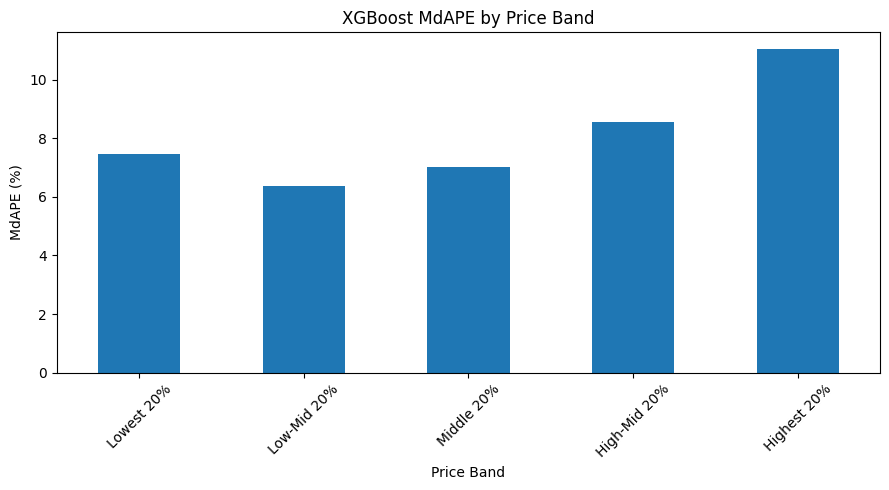

In [42]:
price_band_metrics["MdAPE"].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title(
    "XGBoost MdAPE by Price Band"
)

plt.xlabel(
    "Price Band"
)

plt.ylabel(
    "MdAPE (%)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [43]:
metrics_summary = pd.DataFrame({
    "Model": ["XGBoost"],
    "R2": [r2],
    "MAE": [mae],
    "MAPE": [mape],
    "MdAPE": [mdape]
})

metrics_summary


,Model,R2,MAE,MAPE,MdAPE
0,XGBoost,0.902141,157217.233523,11.744839,7.906717


In [45]:
metrics_summary.to_csv(
    "../results/metrics_summary.csv",
    index=False
)

### Price Band Analysis

The XGBoost model performs best for low-to-mid-priced properties. Homes in the $585,900–$810,000 range achieved the lowest MAPE (9.49%) and MdAPE (6.38%), followed by the middle-price group ($810,186-$1.12M).

Prediction accuracy gradually decreases for higher-priced homes. The highest-price group ($1.68M–$8.18M) had the largest errors,  with a MAPE of 14.08%, MdAPE of 11.07%, and MAE of approximately $411,674.

The lowest-price group also showed a relatively high MAPE of 13.33%, while its MdAPE was only 7.48%. This difference suggests that most lower-priced properties were predicted reasonably well, but a smaller number of large percentage errors increased the average error.

Overall, the model is most accurate for properties in the middle of the price distribution and less accurate at the lower and especially the upper extremes.

### Overall Model Performance

The final XGBoost model achieved an R² of 0.9021 on the held-out test set, indicating that the model explains approximately 90% of the variation in property sale prices.

The model produced a MAPE of 11.74% and a MdAPE of 7.91%. The lower MdAPE relative to MAPE indicates that typical prediction errors are smaller than the average error, suggesting that a smaller number of relatively large errors increase the overall MAPE.